In [19]:
#import necessary packages
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt


In [20]:
#- select a stock
#- download stock data

# define function to gather stock data
def getStockData(ticker, p):

    # turns gathered data into a pandas data frame
    # also gets rid of the dividends and stock splits columns
    data = pd.DataFrame(yf.Ticker(ticker).history(period=p)).iloc[:,:5]

    # adds column for daily return
    data['DailyReturn'] = data['Close'].pct_change()

    # adds a column for the log return
    data['LogReturn'] = np.log(1 + data['Close'].pct_change())

    # removes NaNs
    data = data.dropna()
    
    # select a date range
    # data = data['2018-01-01':'2022-12-31']
    
    # returns the dataframe
    return data

# tickers we will gather data for
# tickers = ['NVDA', "PLTR", "PG", "AMZN", "JPM", "GE", "BSX", "SPY", "QQQ", "DIA"]
tickers = ["AAPL", "AVGO", "JPM"]

# dict to store the data for each ticker
tickerData = {}

# for each ticker 
# gather the data and save it to the dictionary
for ticker in tickers:
    data = getStockData(ticker, '5y')
    tickerData[ticker] = data


    

In [21]:
# combine all stocks log returns into one dataframe
log_returns = pd.DataFrame({ticker: tickerData[ticker]['LogReturn'] for ticker in tickers})

# find mean daily log returns for each stock
mean_daily_returns = log_returns.mean()

# calculate covariance matrix
# tells us how much one stock's movement is correlated with anothers
cov_daily = log_returns.cov()
print(cov_daily)
print('-'*25)

# annualize daily returns and covariance matrix
mean_annual_returns = mean_daily_returns * 252
cov_annual = cov_daily * 252
print(mean_annual_returns)
print('-'*25)
print(cov_annual)

          AAPL      AVGO       JPM
AAPL  0.000299  0.000207  0.000097
AVGO  0.000207  0.000698  0.000127
JPM   0.000097  0.000127  0.000235
-------------------------
AAPL    0.164759
AVGO    0.434866
JPM     0.153681
dtype: float64
-------------------------
          AAPL      AVGO       JPM
AAPL  0.075470  0.052267  0.024345
AVGO  0.052267  0.175773  0.031956
JPM   0.024345  0.031956  0.059234


In [22]:
# export the covariance matrix to a csv file
cov_annual.to_csv('covariance_matrix.csv')

# export the daily covariance matrix to a csv file
cov_daily.to_csv('covariance_matrix_daily.csv')


In [23]:
# simulate random portfolios

# define number of portfolios to simulate
numPortfolios = 10000

# variables to keep track of portfolio returns, volatilities, and Sharpe ratios
portfolioReturns = []
portfolioVolatilities = []
portfolioWeights = []
sharpeRatios = []

# loop to generate random portfolios
for _ in range(numPortfolios):

    # generate random weights for each stock
    weights = np.random.random(len(tickers))

    # normalize weights to sum to 1 (so that the total weight is 100% of portfolio invested)
    weights /= np.sum(weights)

    # compute portfolio return
    # weighted return of annualized returns
    # dot product between weights and returns
    portfolioReturn = np.dot(weights, mean_annual_returns)

    # compute portfolio volatility
    # transpose of weights gives variance
    # sqrt gives standard deviation
    # σ_p​= sqrt(w^TΣw) is used in Modern Portfolio Theory to calculate standard deviation (volatility) of a portfolio's assests
    # note that the np.dot() function actually works as matrix multiplicaiton here not a dot product
    portfolioVolatility = np.sqrt(np.dot(weights.T, np.dot(cov_annual, weights)))

    # find the Sharpe Ratio 
    # ratio used to measure risk adjusted return
    # assuming risk free rate of 0
    sharpeRatio = portfolioReturn / portfolioVolatility

    # store the result in the lists
    portfolioReturns.append(portfolioReturn)
    portfolioVolatilities.append(portfolioVolatility)
    portfolioWeights.append(weights)
    sharpeRatios.append(sharpeRatio)

# Convert lists to numpy arrays for easy indexing
portfolioReturns = np.array(portfolioReturns)
portfolioVolatilities = np.array(portfolioVolatilities)
sharpeRatios = np.array(sharpeRatios)
portfolioWeights = np.array(portfolioWeights)


In [24]:
# analyzing simulated portfolios

# find the portfolio with minimum volatility
# .argmin() returns the index with the minimum value
minVolInd = portfolioVolatilities.argmin()
minVolPortfolio = {
    "Return": float(portfolioReturns[minVolInd]),
    "Volatility": float(portfolioVolatilities[minVolInd]),
    "Weights": portfolioWeights[minVolInd].tolist(),
    "sharpeRatio": float(sharpeRatios[minVolInd])
    }

# find the portfolio with the maximum Sharpe Ratio
maxSharpeInd = sharpeRatios.argmax()
maxSharpePortfolio = {
    "Return": float(portfolioReturns[maxSharpeInd]),
    "Volatility": float(portfolioVolatilities[maxSharpeInd]),
    "Weights": portfolioWeights[maxSharpeInd].tolist(),
    "sharpeRatio": float(sharpeRatios[maxSharpeInd])
    }



In [25]:
# nicer formatting for the return and weights of both portfolios
minVolPortfolioFormatted = {
    "Return": f"{minVolPortfolio['Return']:.2%}",
    "Volatility": f"{minVolPortfolio['Volatility']:.2%}",
    "Weights": {tickers[i]: f"{weight:.2%}" for i, weight in enumerate(minVolPortfolio['Weights'])},
    "SharpeRatio": f"{minVolPortfolio['sharpeRatio']:.2f}"
}

maxSharpePortfolioFormatted = {
    "Return": f"{maxSharpePortfolio['Return']:.2%}",
    "Volatility": f"{maxSharpePortfolio['Volatility']:.2%}",
    "Weights": {tickers[i]: f"{weight:.2%}" for i, weight in enumerate(maxSharpePortfolio['Weights'])},
    "SharpeRatio": f"{maxSharpePortfolio['sharpeRatio']:.2f}"
}

print(f"Maximum Sharpe Ratio Portfolio:")
print(f"Return: {maxSharpePortfolioFormatted['Return']}")
print(f"Volatility: {maxSharpePortfolioFormatted['Volatility']}")
print(f"Sharpe Ratio: {maxSharpePortfolioFormatted['SharpeRatio']}")
print("Weights:")
for ticker, weight in maxSharpePortfolioFormatted['Weights'].items():
    print(f"{ticker}: {weight}")

print("-"*25)
print("*"*25)
print("-"*25)

print(f"Minimum Volatility Portfolio:")
print(f"Return: {minVolPortfolioFormatted['Return']}")
print(f"Volatility: {minVolPortfolioFormatted['Volatility']}")
print(f"Sharpe Ratio: {minVolPortfolioFormatted['SharpeRatio']}")
print("Weights:")
for ticker, weight in minVolPortfolioFormatted['Weights'].items():
    print(f"{ticker}: {weight}")

Maximum Sharpe Ratio Portfolio:
Return: 31.73%
Volatility: 29.16%
Sharpe Ratio: 1.09
Weights:
AAPL: 7.07%
AVGO: 57.93%
JPM: 35.00%
-------------------------
*************************
-------------------------
Minimum Volatility Portfolio:
Return: 16.78%
Volatility: 21.19%
Sharpe Ratio: 0.79
Weights:
AAPL: 38.03%
AVGO: 3.51%
JPM: 58.46%


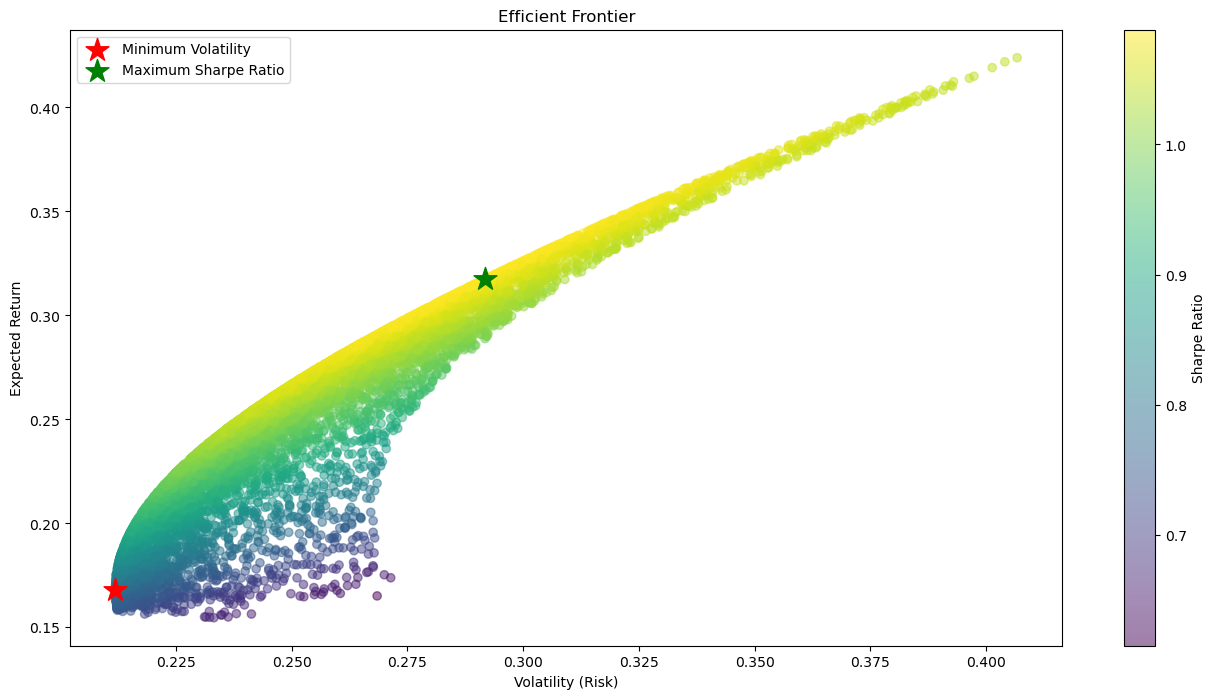

In [26]:
plt.figure(figsize=(16,8))

# plot scatter graph with all portfolios colored by sharpe ratio
plt.scatter(portfolioVolatilities, portfolioReturns, c=sharpeRatios, cmap='viridis', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')

# highlight minimum volatility portfolio
plt.scatter(minVolPortfolio["Volatility"], minVolPortfolio["Return"], color='red', marker='*', s=300, label="Minimum Volatility")

# highlight maximum Sharpe Ratio portfolio
plt.scatter(maxSharpePortfolio["Volatility"], maxSharpePortfolio["Return"], color='green', marker='*', s=300, label="Maximum Sharpe Ratio")


plt.title('Efficient Frontier')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.legend()
plt.show()


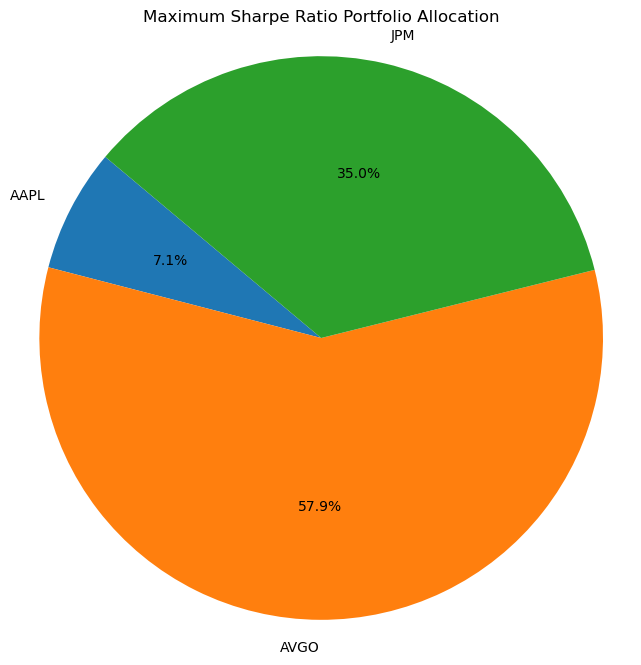

In [27]:
# display the weights of the max sharpe portfolio as a pie chart using matplotlib
plt.figure(figsize=(8,8))
plt.pie(maxSharpePortfolio['Weights'], labels=tickers, autopct='%1.1f%%', startangle=140)
plt.title('Maximum Sharpe Ratio Portfolio Allocation')
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular.
plt.show()